In [1]:
import jax, jax.numpy as jnp

In [2]:
def make_custom_schedule(
    min_lr: float,
    max_lr: float,
    warmup_end: float,
    decay_start: float,
    decay_rate: float = 0.7,
):
    def schedule(step):
        ratio = max_lr / min_lr
        warmup = min_lr * jnp.power(ratio, step / warmup_end)
        constant = max_lr
        decay = max_lr / jnp.power((step - decay_start + 1.0), decay_rate)
        return jnp.where(
            step < warmup_end, warmup, jnp.where(step < decay_start, constant, decay)
        )

    return schedule

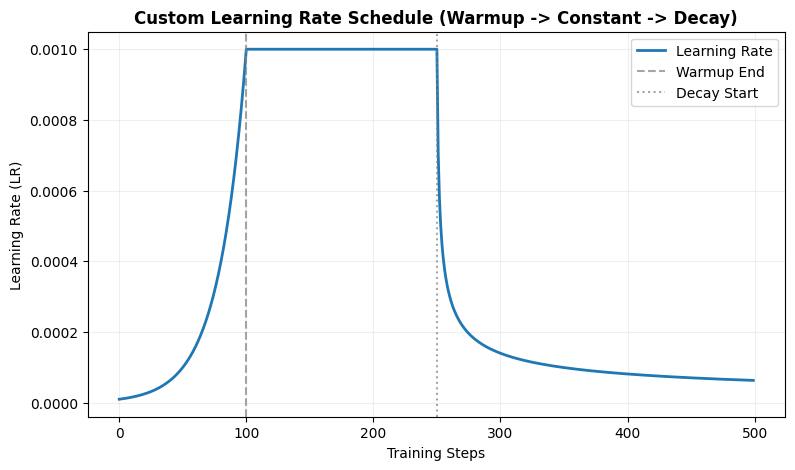

In [4]:

import matplotlib.pyplot as plt
import numpy as np 

def plot_custom_schedule(
    min_lr: float,
    max_lr: float,
    warmup_end: float,
    decay_start: float,
    decay_rate: float = 0.8,
    total_steps: int = 500
):
    """
    Plots the custom learning rate schedule over a given number of total steps.
    """
    # Instantiate the schedule function
    schedule_fn = make_custom_schedule(
        min_lr=min_lr, 
        max_lr=max_lr, 
        warmup_end=warmup_end, 
        decay_start=decay_start, 
        decay_rate=decay_rate
    )
    
    # Generate an array of steps
    steps = jnp.arange(0, total_steps)
    
    # Compute the learning rates for each step
    lr_values = schedule_fn(steps)
    
    # Convert JAX arrays to standard NumPy arrays for Matplotlib
    steps_np = np.array(steps)
    lr_values_np = np.array(lr_values)
    
    # Create the plot
    plt.figure(figsize=(9, 5))
    plt.plot(steps_np, lr_values_np, label="Learning Rate", color="#1f77b4", linewidth=2)
    
    # Add vertical lines to mark phase transitions
    plt.axvline(x=warmup_end, color="gray", linestyle="--", alpha=0.7, label="Warmup End")
    plt.axvline(x=decay_start, color="gray", linestyle=":", alpha=0.7, label="Decay Start")
    
    # Formatting
    plt.title("Custom Learning Rate Schedule (Warmup -> Constant -> Decay)", fontsize=12, fontweight="bold")
    plt.xlabel("Training Steps", fontsize=10)
    plt.ylabel("Learning Rate (LR)", fontsize=10)
    plt.grid(True, linestyle="-", alpha=0.2)
    plt.legend(frameon=True)
    
    plt.show()

# Example Usage:
plot_custom_schedule(
    min_lr=1e-5, 
    max_lr=1e-3, 
    warmup_end=100, 
    decay_start=250, 
    decay_rate=0.5, 
    total_steps=500
)

In [5]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Assuming parametanet and setup_demand_profile are imported as previously defined
import parametanet
from parapersistentExitationSimulation import setup_demand_profile

@jax.jit
def generate_noisy_latent_parameters_simple(key: jax.Array, N: int = 20) -> tuple[jax.Array, jax.Array, jax.Array]:
    """
    Generates latent traffic parameters with spatial AR(1) noise using a simplified, batched approach.
    """
    # 1. Baseline Profiles (Simplified using jnp.where)
    section_indices = jnp.arange(N)
    vf_base = jnp.where(section_indices < N // 2, 120.0, 100.0)
    rho_cr_base = jnp.where(section_indices < N // 2, 32.0, 28.0)
    alpha_base = jnp.full(N, 1.8)

    # 2. Batched White Noise Generation
    # Generate all noise simultaneously: Shape (3 parameters, N sections)
    innovations = jax.random.normal(key, shape=(3, N))
    
    # Scale the innovations by their respective standard deviations (2.0, 0.5, 0.05)
    std_devs = jnp.array([[2.0], [0.5], [0.05]])
    innovations = innovations * std_devs

    # 3. Simplified AR(1) Spatial Loop
    # JAX will unroll this loop efficiently during compilation for static N
    zeta = 0.85
    noise = jnp.zeros((3, N))
    noise = noise.at[:, 0].set(innovations[:, 0])
    
    for i in range(1, N):
        noise = noise.at[:, i].set(zeta * noise[:, i-1] + innovations[:, i])

    # 4. Superimpose and Constrain
    vf_final = jnp.maximum(vf_base + noise[0], 10.0)
    rho_cr_final = jnp.maximum(rho_cr_base + noise[1], 5.0)
    alpha_final = jnp.maximum(alpha_base + noise[2], 0.1)

    return vf_final, rho_cr_final, alpha_final
    return vf_noisy, rho_cr_noisy, alpha_noisy

def run_and_plot_stochastic_simulation():
    N = 20
    T = 10.0 / 3600.0
    steps_per_hour = int(3600 / 10)
    K = 72 * steps_per_hour
    key = jax.random.PRNGKey(42)

    # 1. Generate Noisy Parameters
    key, param_key = jax.random.split(key)
    vf_noisy, rho_cr_noisy, alpha_noisy = generate_noisy_latent_parameters(param_key, N)

    L = jnp.full(N, 0.5)
    lambda_ = jnp.full(N, 1.0)
    
    physical_params = parametanet.NetworkParameters(
        T=T, L=L, lambda_=lambda_,
        tau=0.08, nu=50.0, kappa=40.0, delta=0.012,
        alpha=alpha_noisy, critical_density=rho_cr_noisy, free_flow_speed=vf_noisy
    )
    params = parametanet.to_para_network(physical_params)

    # 2. Setup Demand and Boundaries
    key, demand_key = jax.random.split(key)
    dem = setup_demand_profile(demand_key, K, N, steps_per_hour)

    rho_init = jnp.full(N, 15.0)
    v_init = vf_noisy * jnp.exp(-(1.0 / alpha_noisy) * (rho_init / rho_cr_noisy) ** alpha_noisy)
    q_init = rho_init * v_init * lambda_
    
    init_state = parametanet.NetworkState(density=rho_init, flow=q_init, speed=v_init)
    
    rho0_val = 15.0
    v0_val = 120.0 * jnp.exp(-(1.0 / 1.8) * (rho0_val / 32.0) ** 1.8)
    
    boundaries = parametanet.BoundarySequence(
        q_0=jnp.full(K, rho0_val * v0_val),
        v_0=jnp.full(K, v0_val),
        rho_N_plus_1=jnp.full(K, rho_init[-1]),
        r=dem, s=jnp.zeros((K, N))
    )

    # 3. Execute Rollout
    traj = parametanet.rollout_simulation(init_state, boundaries, params)

    # 4. Plotting Routine
    time_grid, section_grid = np.meshgrid(np.arange(K), np.arange(N))
    fig = plt.figure(figsize=(18, 12))
    
    # Define grid layout: Top row for spatial parameters, Bottom rows for trajectories
    gs = fig.add_gridspec(3, 3, height_ratios=[1, 2, 2])

    # Plot Latent Parameter Spatial Profiles
    ax_vf = fig.add_subplot(gs[0, 0])
    ax_vf.plot(np.arange(N), np.array(vf_noisy), marker='o', color='darkred')
    ax_vf.set_title("Stochastic Free Flow Speed ($v_{fr}$)")
    ax_vf.set_xlabel("Section")
    ax_vf.set_ylabel("Speed (km/h)")

    ax_rho = fig.add_subplot(gs[0, 1])
    ax_rho.plot(np.arange(N), np.array(rho_cr_noisy), marker='s', color='navy')
    ax_rho.set_title("Stochastic Critical Density ($\\rho_{cr}$)")
    ax_rho.set_xlabel("Section")
    ax_rho.set_ylabel("Density (veh/km)")

    ax_alpha = fig.add_subplot(gs[0, 2])
    ax_alpha.plot(np.arange(N), np.array(alpha_noisy), marker='^', color='forestgreen')
    ax_alpha.set_title("Stochastic Shape Parameter ($\\alpha$)")
    ax_alpha.set_xlabel("Section")
    ax_alpha.set_ylabel("Alpha Value")

    # Plot Density Trajectory
    ax_dens = fig.add_subplot(gs[1, :])
    mesh_dens = ax_dens.pcolormesh(time_grid, section_grid, np.array(traj.density).T, cmap="Reds", shading="auto")
    ax_dens.set_title("Freeway Density Trajectory")
    ax_dens.set_ylabel("Section Index")
    fig.colorbar(mesh_dens, ax=ax_dens, label="Density (veh/km)")

    # Plot Speed Trajectory
    ax_speed = fig.add_subplot(gs[2, :])
    mesh_speed = ax_speed.pcolormesh(time_grid, section_grid, np.array(traj.speed).T, cmap="gist_heat", shading="auto")
    ax_speed.set_title("Freeway Velocity Trajectory")
    ax_speed.set_xlabel("Time Step (k)")
    ax_speed.set_ylabel("Section Index")
    fig.colorbar(mesh_speed, ax=ax_speed, label="Speed (km/h)")

    plt.tight_layout()
    plt.show()


run_and_plot_stochastic_simulation()

NameError: name 'generate_noisy_latent_parameters' is not defined